# 01 — BLS LAUS Data

Download and clean BLS Local Area Unemployment Statistics.  
**Output:** `data/interim/laus_panel.parquet` — monthly unemployment rate for 50 states + DC, Jan 2010 – Dec 2024.

In [1]:
import io
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests

In [2]:
RAW_DIR     = Path('../data/raw/bls_laus')
INTERIM_DIR = Path('../data/interim')
FIG_DIR     = Path('../output/figures')

for d in (RAW_DIR, INTERIM_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

BLS_BASE = 'https://download.bls.gov/pub/time.series/la/'
HEADERS  = {'User-Agent': 'academic-research felipemanzife@gmail.com'}

In [3]:
# FIPS (2-digit str) -> 2-letter postal abbreviation
FIPS_TO_ABBREV = {
    '01': 'AL', '02': 'AK', '04': 'AZ', '05': 'AR', '06': 'CA',
    '08': 'CO', '09': 'CT', '10': 'DE', '11': 'DC', '12': 'FL',
    '13': 'GA', '15': 'HI', '16': 'ID', '17': 'IL', '18': 'IN',
    '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME',
    '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS',
    '29': 'MO', '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH',
    '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND',
    '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI',
    '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT',
    '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI',
    '56': 'WY',
}

In [4]:
def fetch_bls_file(filename: str) -> pd.DataFrame:
    """Download a BLS flat file, cache to disk, return as DataFrame."""
    local = RAW_DIR / filename
    if not local.exists():
        print(f'Downloading {filename}...')
        r = requests.get(BLS_BASE + filename, headers=HEADERS, timeout=120)
        r.raise_for_status()
        local.write_bytes(r.content)
        print(f'  saved {local.stat().st_size / 1e6:.1f} MB')
    else:
        print(f'Using cached {filename}')
    return pd.read_csv(local, sep='\t', dtype=str)

## Download source files

In [5]:
raw_data   = fetch_bls_file('la.data.3.AllStatesS')
raw_series = fetch_bls_file('la.series')
raw_area   = fetch_bls_file('la.area')

Using cached la.data.3.AllStatesS
Using cached la.series
Using cached la.area


In [6]:
# Strip whitespace from all column names and string values
def strip_df(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = df.columns.str.strip()
    return df.apply(lambda c: c.str.strip() if c.dtype == object else c)

raw_data   = strip_df(raw_data)
raw_series = strip_df(raw_series)
raw_area   = strip_df(raw_area)

print('data shape:', raw_data.shape)
print(raw_data.head(3))
print()
print('series columns:', raw_series.columns.tolist())
print('area columns:  ', raw_area.columns.tolist())

data shape: (186930, 5)
                        series_id  year period         value footnote_codes
0  LASST010000000000003            1976    M01           6.7            NaN
1  LASST010000000000003            1976    M02           6.6            NaN
2  LASST010000000000003            1976    M03           6.6            NaN

series columns: ['series_id', 'area_type_code', 'area_code', 'measure_code', 'seasonal', 'srd_code', 'series_title', 'footnote_codes', 'begin_year', 'begin_period', 'end_year', 'end_period']
area columns:   ['area_type_code', 'area_code', 'area_text', 'display_level', 'selectable', 'sort_sequence']


## Filter series metadata to state-level, seasonally adjusted, unemployment rate

In [7]:
# area_type_code='A' → 50 states + DC
# measure_code='03'  → unemployment rate
# seasonal='S'       → seasonally adjusted
series_sa = raw_series[
    (raw_series['area_type_code'] == 'A') &
    (raw_series['measure_code']   == '03') &
    (raw_series['seasonal']       == 'S')
].copy()

print(f'{len(series_sa)} SA unemployment-rate series for states/DC')
print(series_sa[['series_id', 'area_code', 'series_title']].head(3))

52 SA unemployment-rate series for states/DC
                          series_id        area_code  \
112  LASST010000000000003            ST0100000000000   
118  LASST020000000000003            ST0200000000000   
124  LASST040000000000003            ST0400000000000   

                       series_title  
112  Unemployment Rate: Alabama (S)  
118   Unemployment Rate: Alaska (S)  
124  Unemployment Rate: Arizona (S)  


In [8]:
# Extract 2-digit state FIPS from area_code: 'ST0100000000000' -> '01'
series_sa['state_fips'] = series_sa['area_code'].str[2:4]

# Keep only the 51 jurisdictions in our FIPS map
series_sa = series_sa[series_sa['state_fips'].isin(FIPS_TO_ABBREV)].copy()
series_sa['state_code'] = series_sa['state_fips'].map(FIPS_TO_ABBREV)

# Add state name from la.area (area_type_code='A')
area_states = raw_area[raw_area['area_type_code'] == 'A'][['area_code', 'area_text']].copy()
area_states.columns = ['area_code', 'state_name']
series_sa = series_sa.merge(area_states, on='area_code', how='left')

print(f'{len(series_sa)} series after geographic filter')
print(series_sa[['series_id', 'state_code', 'state_name']].head(5))

51 series after geographic filter
                        series_id state_code  state_name
0  LASST010000000000003                   AL     Alabama
1  LASST020000000000003                   AK      Alaska
2  LASST040000000000003                   AZ     Arizona
3  LASST050000000000003                   AR    Arkansas
4  LASST060000000000003                   CA  California


## Merge observations with series metadata

In [9]:
# Keep only series IDs we care about to avoid joining all 12k+ series
target_ids = set(series_sa['series_id'])
data_filtered = raw_data[raw_data['series_id'].isin(target_ids)].copy()

print(f'Raw observations for our series: {len(data_filtered):,}')
print(data_filtered.head(3))

Raw observations for our series: 30,753
                        series_id  year period         value footnote_codes
0  LASST010000000000003            1976    M01           6.7            NaN
1  LASST010000000000003            1976    M02           6.6            NaN
2  LASST010000000000003            1976    M03           6.6            NaN


In [10]:
# Merge with series metadata
df = data_filtered.merge(
    series_sa[['series_id', 'state_code', 'state_name']],
    on='series_id', how='left'
)

# Parse year and month; drop annual averages (M13)
df['year']  = df['year'].astype(int)
df['month'] = df['period'].str[1:].astype(int)   # 'M01' -> 1
df = df[df['month'] <= 12].copy()                 # drop M13 annual avg

# Parse unemployment rate; drop suppressed values ('-')
df['unemployment_rate'] = pd.to_numeric(df['value'], errors='coerce')
df = df.dropna(subset=['unemployment_rate'])

# Build date column (first day of each month)
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

print(df.dtypes)
print(df.head(3))

series_id                       str
year                          int64
period                          str
value                           str
footnote_codes                  str
state_code                      str
state_name                      str
month                         int64
unemployment_rate           float64
date                 datetime64[us]
dtype: object
                        series_id  year period         value footnote_codes  \
0  LASST010000000000003            1976    M01           6.7            NaN   
1  LASST010000000000003            1976    M02           6.6            NaN   
2  LASST010000000000003            1976    M03           6.6            NaN   

  state_code state_name  month  unemployment_rate       date  
0         AL    Alabama      1                6.7 1976-01-01  
1         AL    Alabama      2                6.6 1976-02-01  
2         AL    Alabama      3                6.6 1976-03-01  


## Apply time window: Jan 2010 – Dec 2024

In [11]:
df = df[(df['date'] >= '2010-01-01') & (df['date'] <= '2024-12-01')].copy()

# Select and order final columns
panel = (
    df[['state_code', 'state_name', 'year', 'month', 'date', 'unemployment_rate']]
    .sort_values(['state_code', 'date'])
    .reset_index(drop=True)
)

print('Panel shape:', panel.shape)
print('States:', panel['state_code'].nunique())
print('Date range:', panel['date'].min(), '—', panel['date'].max())
print()
print('First 5 rows:')
print(panel.head())
print()
print('Last 5 rows:')
print(panel.tail())

Panel shape: (9180, 6)
States: 51
Date range: 2010-01-01 00:00:00 — 2024-12-01 00:00:00

First 5 rows:
  state_code state_name  year  month       date  unemployment_rate
0         AK     Alaska  2010      1 2010-01-01                8.3
1         AK     Alaska  2010      2 2010-02-01                8.3
2         AK     Alaska  2010      3 2010-03-01                8.2
3         AK     Alaska  2010      4 2010-04-01                8.1
4         AK     Alaska  2010      5 2010-05-01                8.0

Last 5 rows:
     state_code state_name  year  month       date  unemployment_rate
9175         WY    Wyoming  2024      8 2024-08-01                3.2
9176         WY    Wyoming  2024      9 2024-09-01                3.3
9177         WY    Wyoming  2024     10 2024-10-01                3.3
9178         WY    Wyoming  2024     11 2024-11-01                3.3
9179         WY    Wyoming  2024     12 2024-12-01                3.3


In [12]:
# Quick summary by state
summary = (
    panel.groupby(['state_code', 'state_name'])['unemployment_rate']
    .agg(['count', 'mean', 'min', 'max'])
    .round(2)
    .rename(columns={'count': 'n_months', 'mean': 'avg_ur', 'min': 'min_ur', 'max': 'max_ur'})
)
print(summary.to_string())

                                 n_months  avg_ur  min_ur  max_ur
state_code state_name                                            
AK         Alaska                     180    6.36     3.9    11.7
AL         Alabama                    180    5.57     2.3    13.8
AR         Arkansas                   180    5.05     2.9    10.1
AZ         Arizona                    180    6.20     3.4    13.8
CA         California                 180    7.18     3.8    16.1
CO         Colorado                   180    5.03     2.4    11.7
CT         Connecticut                180    5.92     3.1    11.9
DC         District of Columbia       180    7.01     4.0    11.3
DE         Delaware                   180    5.39     3.5    13.4
FL         Florida                    180    5.85     2.8    14.1
GA         Georgia                    180    5.92     3.0    12.5
HI         Hawaii                     180    4.55     2.0    22.5
IA         Iowa                       180    3.96     2.5    11.0
ID        

In [13]:
# Confirm balanced panel: every state should have 180 months
months_per_state = panel.groupby('state_code')['date'].nunique()
assert (months_per_state == 180).all(), f'Unbalanced panel: {months_per_state[months_per_state != 180]}'
print('Panel is balanced: 180 months x 51 states =', panel.shape[0], 'rows ✓')

Panel is balanced: 180 months x 51 states = 9180 rows ✓


## Save to parquet

In [14]:
out_path = INTERIM_DIR / 'laus_panel.parquet'
panel.to_parquet(out_path, index=False)
print(f'Saved {out_path}  ({out_path.stat().st_size / 1e3:.0f} KB)')

Saved ../data/interim/laus_panel.parquet  (14 KB)


## EDA — 6 representative states

Figure saved: ../output/figures/01_laus_eda.png


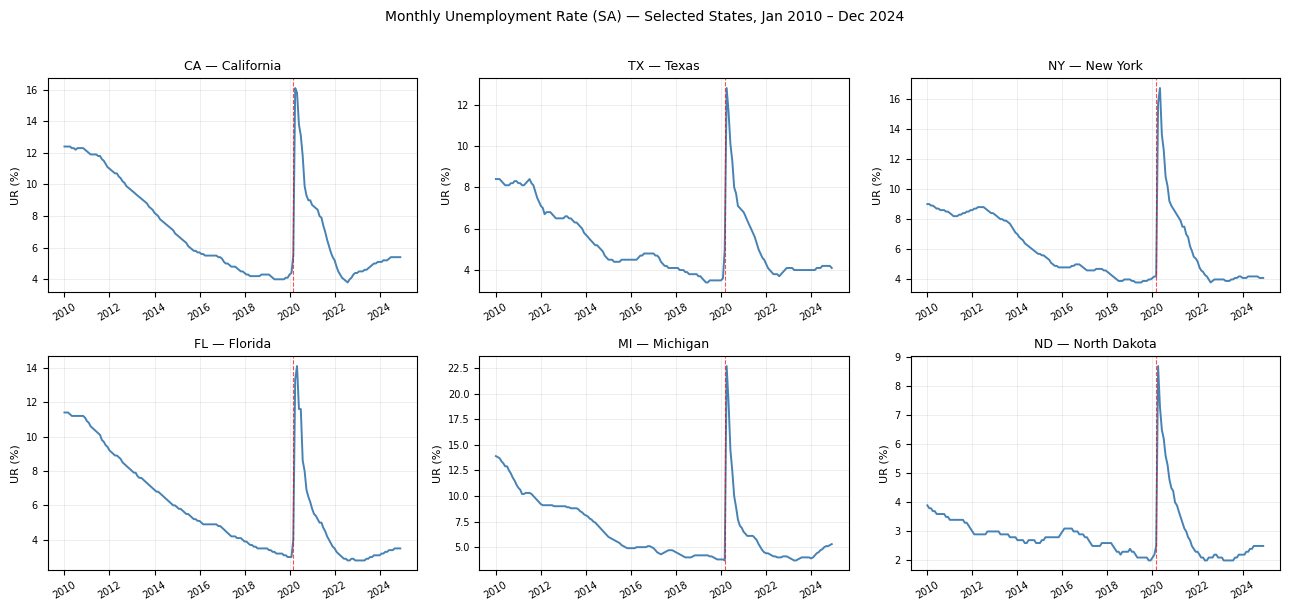

In [15]:
STATES_6 = ['CA', 'TX', 'NY', 'FL', 'MI', 'ND']
sub = panel[panel['state_code'].isin(STATES_6)].copy()

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=False)
axes = axes.flatten()

for ax, code in zip(axes, STATES_6):
    s = sub[sub['state_code'] == code]
    name = s['state_name'].iloc[0]
    ax.plot(s['date'], s['unemployment_rate'], linewidth=1.4, color='steelblue')
    ax.axvline(pd.Timestamp('2020-03-01'), color='red', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.set_title(f'{code} — {name}', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('UR (%)', fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.3, linewidth=0.5)

fig.suptitle('Monthly Unemployment Rate (SA) — Selected States, Jan 2010 – Dec 2024',
             fontsize=10, y=1.01)
fig.tight_layout()

out_fig = FIG_DIR / '01_laus_eda.png'
fig.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Figure saved: {out_fig}')
plt.show()

---
## Part 2 — Sahm Rule Onset Variable

State-level adaptation of the Sahm Rule. Fires on the **first** month the 3-month moving average of the unemployment rate exceeds its prior-12-month minimum by a given threshold — onset, not prevalence.

In [16]:
import io
import requests

FRED_HEADERS = {'User-Agent': 'academic-research felipemanzife@gmail.com'}
FRED_RAW_DIR = Path('../data/raw/fred')
FRED_RAW_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_parquet(INTERIM_DIR / 'laus_panel.parquet')
print('Loaded panel:', panel.shape)

Loaded panel: (9180, 6)


In [17]:
def build_sahm_shock(df: pd.DataFrame, threshold: float = 0.5,
                     ma_window: int = 3, lookback: int = 12) -> pd.DataFrame:
    """Add ma3, sahm_gap, and first-crossing shock column to the panel."""
    shock_col = f'shock_sahm_{int(round(threshold * 10)):02d}'
    results = []
    for _, group in df.groupby('state_code', sort=True):
        g = group.sort_values('date').copy()
        g['ma3']      = g['unemployment_rate'].rolling(ma_window, min_periods=ma_window).mean()
        g['min12']    = g['ma3'].shift(1).rolling(lookback, min_periods=lookback).min()
        g['sahm_gap'] = g['ma3'] - g['min12']
        above         = (g['sahm_gap'] >= threshold).astype(int)
        above_prev    = above.shift(1).fillna(0).astype(int)
        g[shock_col]  = ((above == 1) & (above_prev == 0)).astype(int)
        results.append(g)
    return (pd.concat(results, ignore_index=True)
              .sort_values(['state_code', 'date'])
              .reset_index(drop=True))

In [18]:
# Build base from threshold=0.5 (includes ma3 and sahm_gap)
df05 = build_sahm_shock(panel, threshold=0.5)

# Append shock columns for 0.3 and 0.7 — reuse already-computed sahm_gap
for thr in [0.3, 0.7]:
    col = f'shock_sahm_{int(round(thr * 10)):02d}'
    tmp = build_sahm_shock(panel, threshold=thr)[['state_code', 'date', col]]
    df05 = df05.merge(tmp, on=['state_code', 'date'], how='left')

# Drop helper column; keep ma3 and sahm_gap as model features
panel_shocks = df05.drop(columns=['min12'])
print(panel_shocks.columns.tolist())
print(panel_shocks.shape)

['state_code', 'state_name', 'year', 'month', 'date', 'unemployment_rate', 'ma3', 'sahm_gap', 'shock_sahm_05', 'shock_sahm_03', 'shock_sahm_07']
(9180, 11)


### Validation

In [19]:
# (a) Total shock counts and base rates
print('=== (a) Shock counts and base rates ===')
valid_n = panel_shocks['sahm_gap'].notna().sum()
for col, thr in [('shock_sahm_03', 0.3), ('shock_sahm_05', 0.5), ('shock_sahm_07', 0.7)]:
    n  = int(panel_shocks[col].sum())
    br = n / valid_n * 100
    print(f'  threshold={thr}:  {n:3d} shocks   base_rate={br:.1f}%')

# Guard
n05 = int(panel_shocks['shock_sahm_05'].sum())
assert 50 <= n05 <= 400, f'UNEXPECTED shock count for 0.5 threshold: {n05}'
print(f'\n  ✓ threshold=0.5 count ({n05}) is in expected range [50, 400]')

=== (a) Shock counts and base rates ===
  threshold=0.3:  138 shocks   base_rate=1.6%
  threshold=0.5:  101 shocks   base_rate=1.2%
  threshold=0.7:   73 shocks   base_rate=0.9%

  ✓ threshold=0.5 count (101) is in expected range [50, 400]


In [20]:
# (b) Shocks per state — full table sorted descending
print('=== (b) Shocks per state (threshold=0.5) ===')
by_state = (panel_shocks
            .groupby(['state_code', 'state_name'])['shock_sahm_05']
            .sum().astype(int)
            .sort_values(ascending=False)
            .rename('n_shocks'))
print(by_state.to_string())

=== (b) Shocks per state (threshold=0.5) ===
state_code  state_name          
LA          Louisiana               4
DC          District of Columbia    4
MS          Mississippi             3
IA          Iowa                    3
SC          South Carolina          3
NM          New Mexico              3
NE          Nebraska                3
IL          Illinois                3
WY          Wyoming                 3
CO          Colorado                3
FL          Florida                 2
MT          Montana                 2
WV          West Virginia           2
WA          Washington              2
VT          Vermont                 2
UT          Utah                    2
AR          Arkansas                2
RI          Rhode Island            2
OR          Oregon                  2
OK          Oklahoma                2
OH          Ohio                    2
NY          New York                2
AZ          Arizona                 2
NJ          New Jersey              2
CA        

In [21]:
# (c) Shocks per year
print('=== (c) Shocks per year (threshold=0.5) ===')
by_year = panel_shocks.groupby('year')['shock_sahm_05'].sum().astype(int)
print(by_year.to_string())
print(f'\n  2020 alone: {int(by_year.get(2020, 0))} of {int(by_year.sum())} total '
      f'({int(by_year.get(2020,0))/by_year.sum()*100:.0f}%)')

=== (c) Shocks per year (threshold=0.5) ===
year
2010     0
2011     3
2012     1
2013     0
2014     2
2015     1
2016     3
2017     0
2018     2
2019     3
2020    49
2021     0
2022     1
2023    14
2024    22

  2020 alone: 49 of 101 total (49%)


In [22]:
# (d) Months between consecutive shocks (same state)
print('=== (d) Months between consecutive shocks ===')
gaps = []
for _, g in panel_shocks.groupby('state_code'):
    sdates = g.loc[g['shock_sahm_05'] == 1, 'date'].sort_values().tolist()
    for i in range(len(sdates) - 1):
        a, b = sdates[i], sdates[i + 1]
        gaps.append((b.year - a.year) * 12 + (b.month - a.month))

s = pd.Series(gaps, name='months_between_shocks')
print(s.describe().round(1).to_string())
print(f'\n  Min gap: {s.min()} months  (>= 1 guaranteed by first-crossing construction)')
print(f'  Back-to-back (gap==1): {(s == 1).sum()}')

=== (d) Months between consecutive shocks ===
count     50.0
mean      46.2
std       18.8
min        2.0
25%       40.2
50%       45.0
75%       49.0
max      107.0

  Min gap: 2 months  (>= 1 guaranteed by first-crossing construction)
  Back-to-back (gap==1): 0


In [23]:
# (e) First shock date in 2020 per state
print('=== (e) First 2020 shock per state (threshold=0.5) ===')
shocks_2020 = panel_shocks[(panel_shocks['shock_sahm_05'] == 1) & (panel_shocks['year'] == 2020)]
first_2020  = shocks_2020.groupby('state_code')['date'].min().sort_values()
print(first_2020.dt.strftime('%Y-%m').to_string())
mar_may = ((first_2020 >= '2020-03-01') & (first_2020 <= '2020-05-31')).sum()
print(f'\n  States firing Mar–May 2020: {mar_may} of {len(first_2020)}')
print(f'  States NOT firing at all in 2020: {51 - len(first_2020)}')

=== (e) First 2020 shock per state (threshold=0.5) ===
state_code
CO    2020-02
DE    2020-03
WA    2020-03
AR    2020-03
IL    2020-03
CA    2020-03
OH    2020-03
NM    2020-03
LA    2020-03
TX    2020-03
NV    2020-03
SC    2020-03
AK    2020-04
NH    2020-04
NE    2020-04
NY    2020-04
OK    2020-04
RI    2020-04
PA    2020-04
ND    2020-04
SD    2020-04
TN    2020-04
UT    2020-04
VA    2020-04
VT    2020-04
OR    2020-04
NC    2020-04
MO    2020-04
MS    2020-04
AL    2020-04
AZ    2020-04
CT    2020-04
DC    2020-04
FL    2020-04
GA    2020-04
HI    2020-04
IA    2020-04
MT    2020-04
ID    2020-04
KS    2020-04
KY    2020-04
MA    2020-04
MD    2020-04
ME    2020-04
MI    2020-04
MN    2020-04
WI    2020-04
IN    2020-04
WV    2020-04

  States firing Mar–May 2020: 48 of 49
  States NOT firing at all in 2020: 2


In [24]:
# (f) Spot-check: our national Sahm gap vs FRED SAHMCURRENT
print('=== (f) National Sahm gap vs FRED SAHMCURRENT ===')

def fetch_fred(series_id: str) -> pd.DataFrame:
    local = FRED_RAW_DIR / f'{series_id}.csv'
    if not local.exists():
        r = requests.get(
            f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}',
            headers=FRED_HEADERS, timeout=30)
        r.raise_for_status()
        local.write_bytes(r.content)
    df = pd.read_csv(local)
    df.columns = ['date', series_id]
    df['date'] = pd.to_datetime(df['date'])
    df[series_id] = pd.to_numeric(df[series_id], errors='coerce')
    return df[(df['date'] >= '2010-01-01') & (df['date'] <= '2024-12-01')].reset_index(drop=True)

sahmcurr = fetch_fred('SAHMCURRENT')
unrate   = fetch_fred('UNRATE').sort_values('date').copy()

unrate['ma3_nat']   = unrate['UNRATE'].rolling(3, min_periods=3).mean()
unrate['min12_nat'] = unrate['ma3_nat'].shift(1).rolling(12, min_periods=12).min()
unrate['our_sahm']  = unrate['ma3_nat'] - unrate['min12_nat']

comp = unrate[['date', 'our_sahm']].merge(sahmcurr, on='date').dropna()
corr     = comp['our_sahm'].corr(comp['SAHMCURRENT'])
max_diff = (comp['our_sahm'] - comp['SAHMCURRENT']).abs().max()
print(f'  Pearson r = {corr:.4f}')
print(f'  Max |diff| = {max_diff:.2f} pp')
print()
print(comp[['date', 'our_sahm', 'SAHMCURRENT']].tail(12).to_string(index=False))

=== (f) National Sahm gap vs FRED SAHMCURRENT ===


  Pearson r = 1.0000
  Max |diff| = 0.00 pp

      date  our_sahm  SAHMCURRENT
2024-01-01  0.233333         0.23
2024-02-01  0.300000         0.30
2024-03-01  0.333333         0.33
2024-04-01  0.400000         0.40
2024-05-01  0.400000         0.40
2024-06-01  0.433333         0.43
2024-07-01  0.500000         0.50
2024-08-01  0.566667         0.57
2024-09-01  0.533333         0.53
2024-10-01  0.400000         0.40
2024-11-01  0.400000         0.40
2024-12-01  0.400000         0.40


### EDA charts

Saved ../output/figures/01_sahm_shocks_per_year.png


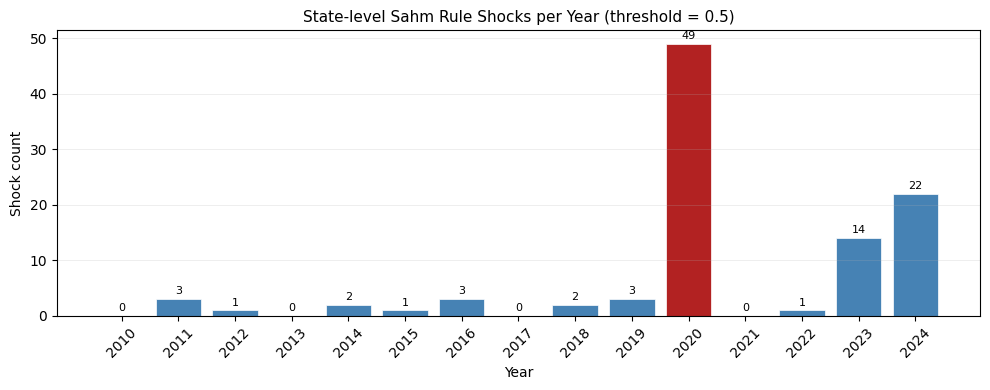

In [25]:
# Chart 1: Shocks per year (threshold=0.5)
by_year_all = panel_shocks.groupby('year')['shock_sahm_05'].sum().astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['firebrick' if y == 2020 else 'steelblue' for y in by_year_all.index]
bars = ax.bar(by_year_all.index, by_year_all.values, color=colors, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, padding=2, fontsize=8)
ax.set_xlabel('Year')
ax.set_ylabel('Shock count')
ax.set_title('State-level Sahm Rule Shocks per Year (threshold = 0.5)', fontsize=11)
ax.set_xticks(by_year_all.index)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
fig.tight_layout()

out1 = FIG_DIR / '01_sahm_shocks_per_year.png'
fig.savefig(out1, dpi=150, bbox_inches='tight')
print(f'Saved {out1}')
plt.show()

Saved ../output/figures/01_sahm_shocks_examples.png


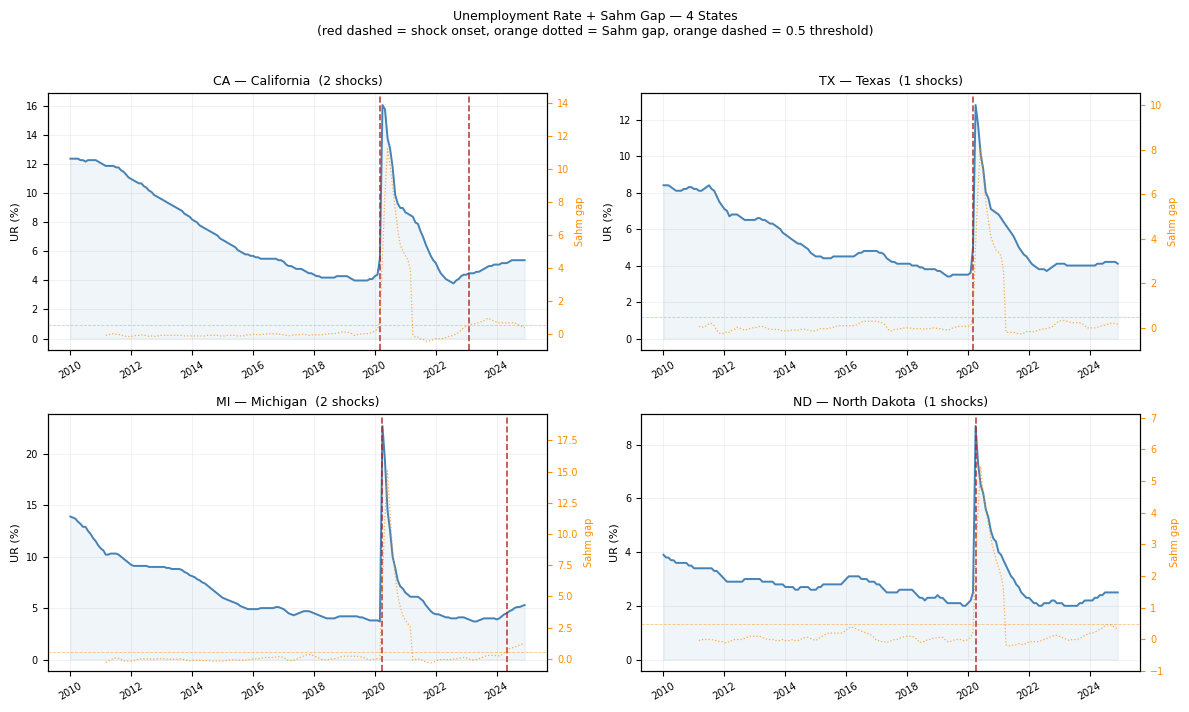

In [26]:
# Chart 2: 4-state examples with shock markers
STATES_4 = ['CA', 'TX', 'MI', 'ND']
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=False)
axes = axes.flatten()

for ax, code in zip(axes, STATES_4):
    s = panel_shocks[panel_shocks['state_code'] == code].sort_values('date')
    name = s['state_name'].iloc[0]

    ax.plot(s['date'], s['unemployment_rate'], color='steelblue', linewidth=1.4, label='UR')
    ax.fill_between(s['date'], s['unemployment_rate'], alpha=0.08, color='steelblue')

    shock_dates = s.loc[s['shock_sahm_05'] == 1, 'date']
    for d in shock_dates:
        ax.axvline(d, color='firebrick', linewidth=1.2, alpha=0.85, linestyle='--')

    # Annotate threshold crossing with gap
    ax2 = ax.twinx()
    ax2.plot(s['date'], s['sahm_gap'], color='darkorange', linewidth=0.9, alpha=0.7, linestyle=':')
    ax2.axhline(0.5, color='darkorange', linewidth=0.6, linestyle='--', alpha=0.5)
    ax2.set_ylabel('Sahm gap', fontsize=7, color='darkorange')
    ax2.tick_params(axis='y', labelsize=7, colors='darkorange')
    ax2.set_ylim(-1, max(s['sahm_gap'].max() * 1.3, 1.5))

    ax.set_title(f'{code} — {name}  ({len(shock_dates)} shocks)', fontsize=9)
    ax.set_ylabel('UR (%)', fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.25, linewidth=0.5)

fig.suptitle('Unemployment Rate + Sahm Gap — 4 States\n'
             '(red dashed = shock onset, orange dotted = Sahm gap, orange dashed = 0.5 threshold)',
             fontsize=9, y=1.01)
fig.tight_layout()

out2 = FIG_DIR / '01_sahm_shocks_examples.png'
fig.savefig(out2, dpi=150, bbox_inches='tight')
print(f'Saved {out2}')
plt.show()

Saved ../output/figures/01_sahm_gap_distribution.png


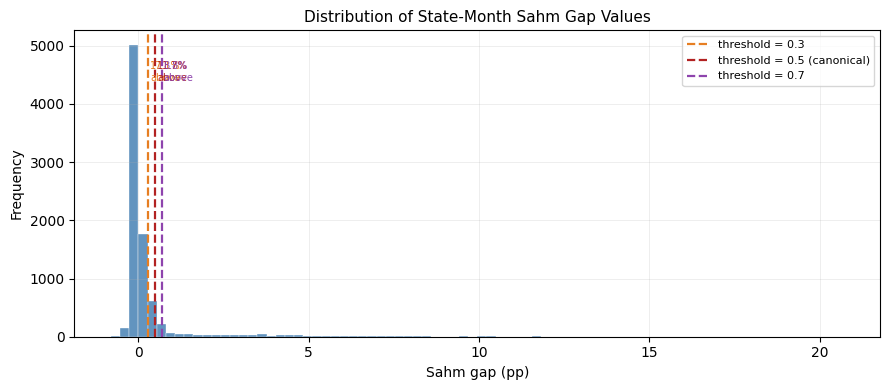

In [27]:
# Chart 3: Distribution of sahm_gap values with threshold lines
gap_vals = panel_shocks['sahm_gap'].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(gap_vals, bins=80, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.85)

for thr, col, lbl in [(0.3,'#e67e22','0.3'), (0.5,'firebrick','0.5 (canonical)'), (0.7,'#8e44ad','0.7')]:
    ax.axvline(thr, color=col, linewidth=1.6, linestyle='--', label=f'threshold = {lbl}')
    pct = (gap_vals >= thr).mean() * 100
    ax.text(thr + 0.05, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 10,
            f'{pct:.1f}%\nabove', fontsize=7, color=col, va='top')

ax.set_xlabel('Sahm gap (pp)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of State-Month Sahm Gap Values', fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, linewidth=0.5)
fig.tight_layout()

out3 = FIG_DIR / '01_sahm_gap_distribution.png'
fig.savefig(out3, dpi=150, bbox_inches='tight')
print(f'Saved {out3}')
plt.show()

### Save enriched panel

In [28]:
# Final column selection
panel_out = panel_shocks[[
    'state_code', 'state_name', 'year', 'month', 'date',
    'unemployment_rate', 'ma3', 'sahm_gap',
    'shock_sahm_03', 'shock_sahm_05', 'shock_sahm_07'
]].copy()

print('Final panel shape:', panel_out.shape)
print('Shock counts:')
for col in ['shock_sahm_03', 'shock_sahm_05', 'shock_sahm_07']:
    print(f'  {col}: {int(panel_out[col].sum())}  '
          f'(NaN rows excluded from denominator: '
          f'{panel_out[col].isna().sum()})')

out_path = INTERIM_DIR / 'laus_panel_with_shocks.parquet'
panel_out.to_parquet(out_path, index=False)
print(f'\nSaved {out_path}  ({out_path.stat().st_size / 1e3:.0f} KB)')

Final panel shape: (9180, 11)
Shock counts:
  shock_sahm_03: 138  (NaN rows excluded from denominator: 0)
  shock_sahm_05: 101  (NaN rows excluded from denominator: 0)
  shock_sahm_07: 73  (NaN rows excluded from denominator: 0)

Saved ../data/interim/laus_panel_with_shocks.parquet  (46 KB)
